In [46]:
import pandas as pd

matches = pd.read_csv("/content/EDA-IPL/data/matches.csv")

top_10_venues = matches['venue'].value_counts().head(10)
top_10_venues_df = top_10_venues.reset_index()
top_10_venues_df.columns = ['venue', 'matches_hosted']

print(top_10_venues_df)

                                        venue  matches_hosted
0                                Eden Gardens              77
1                            Wankhede Stadium              73
2                       M Chinnaswamy Stadium              65
3                            Feroz Shah Kotla              60
4   Rajiv Gandhi International Stadium, Uppal              49
5             MA Chidambaram Stadium, Chepauk              48
6                      Sawai Mansingh Stadium              47
7         Dubai International Cricket Stadium              46
8                    Wankhede Stadium, Mumbai              45
9  Punjab Cricket Association Stadium, Mohali              35


In [47]:
filtered_matches = matches[matches['venue'].isin(top_10_venues.index)].copy()

early_ipl_seasons = filtered_matches[filtered_matches['season'] < '2015'].copy()
modern_ipl_seasons = filtered_matches[filtered_matches['season'] >= '2015'].copy()

def calculate_venue_stats(df, era_name, top_venues_index):
    venue_stats = []
    for venue in top_venues_index:
        venue_matches = df[df['venue'] == venue]
        total_matches = len(venue_matches)

        if total_matches == 0:
            continue

        bat_first_wins = 0
        chase_wins = 0

        for index, row in venue_matches.iterrows():
            bat_first_team = None
            if row['toss_decision'] == 'bat':
                bat_first_team = row['toss_winner']
            else:
                bat_first_team = row['team1'] if row['toss_winner'] == row['team2'] else row['team2']

            if bat_first_team == row['winner']:
                bat_first_wins += 1
            else:
                chase_wins += 1

        venue_stats.append({
            'venue': venue,
            'era': era_name,
            'bat_first_win_ratio': bat_first_wins / total_matches,
            'chase_win_ratio': chase_wins / total_matches
        })
    return pd.DataFrame(venue_stats)


early_ipl_df = calculate_venue_stats(early_ipl_seasons, 'Early IPL', top_10_venues.index)
modern_ipl_df = calculate_venue_stats(modern_ipl_seasons, 'Modern IPL', top_10_venues.index)


combined_df = pd.concat([early_ipl_df, modern_ipl_df]).reset_index(drop=True)
display(combined_df)

,venue,era,bat_first_win_ratio,chase_win_ratio
0,Eden Gardens,Early IPL,0.375000,0.625000
1,Wankhede Stadium,Early IPL,0.513514,0.486486
2,M Chinnaswamy Stadium,Early IPL,0.404762,0.595238
3,Feroz Shah Kotla,Early IPL,0.439024,0.560976
4,"Rajiv Gandhi International Stadium, Uppal",Early IPL,0.333333,0.666667
5,"MA Chidambaram Stadium, Chepauk",Early IPL,0.609756,0.390244
6,Sawai Mansingh Stadium,Early IPL,0.303030,0.696970
7,Dubai International Cricket Stadium,Early IPL,0.428571,0.571429
8,"Punjab Cricket Association Stadium, Mohali",Early IPL,0.387097,0.612903
9,Eden Gardens,Modern IPL,0.405405,0.594595


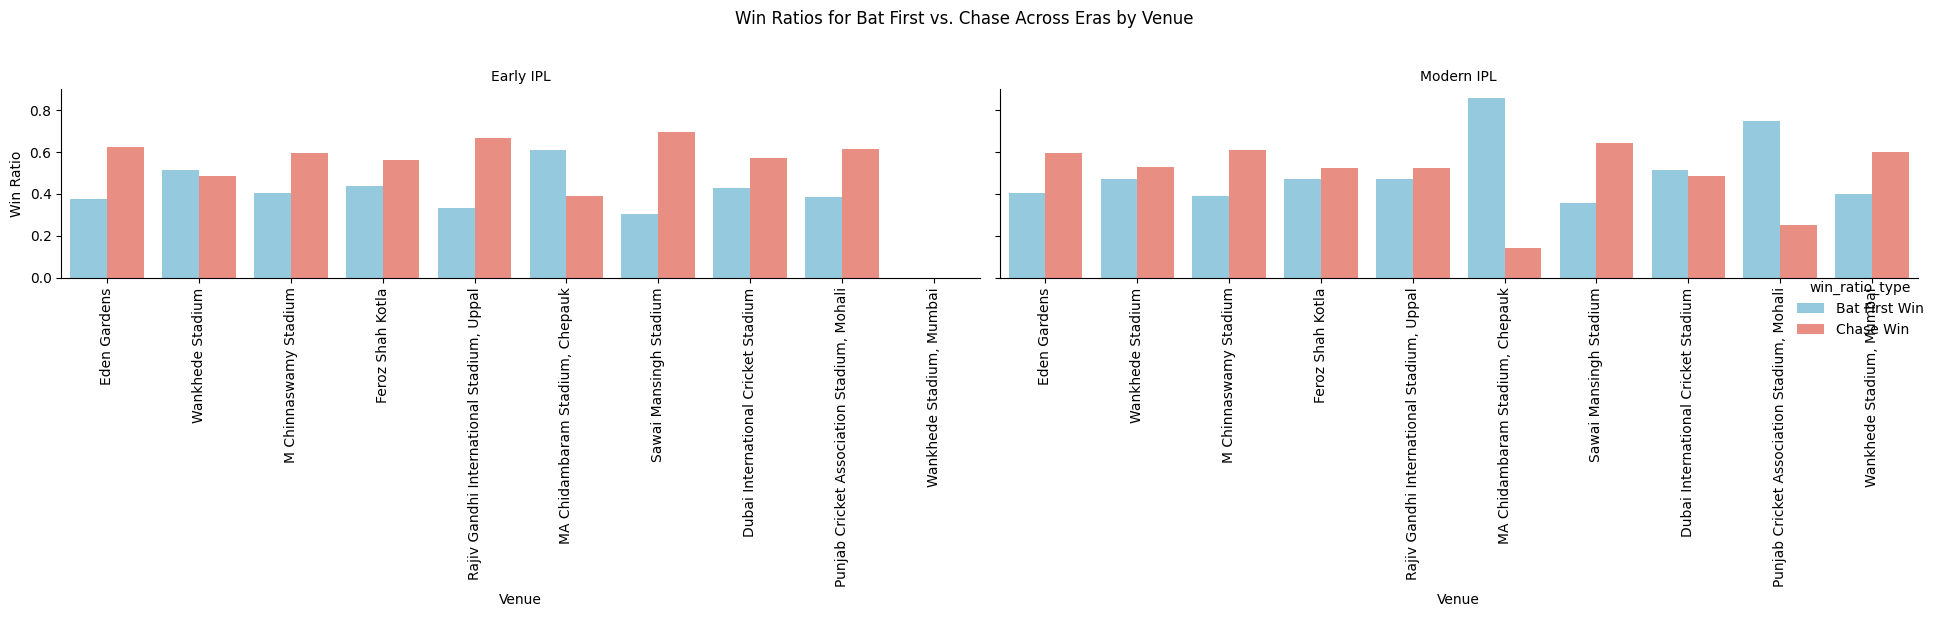

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = combined_df.melt(id_vars=['venue', 'era'],value_vars=['bat_first_win_ratio', 'chase_win_ratio'],var_name='win_ratio_type', value_name='win_ratio')

plot_df['win_ratio_type'] = plot_df['win_ratio_type'].map({'bat_first_win_ratio': 'Bat First Win','chase_win_ratio': 'Chase Win'
})


g = sns.catplot(data=plot_df, x='venue', y='win_ratio', hue='win_ratio_type', col='era',
                kind='bar', palette={'Bat First Win': 'skyblue', 'Chase Win': 'salmon'},
                height=6, aspect=1.5, sharey=True)


g.set_axis_labels("Venue", "Win Ratio")
g.set_xticklabels(rotation=90)
g.set_titles("{col_name}")
plt.suptitle('Win Ratios for Bat First vs. Chase Across Eras by Venue', y=1.02)
plt.tight_layout()
plt.show()